## Description of Program
- program:    ncoda_08av1_HUEstimate
- task:       Explore Housing Unit Estimate File
- See github commits for description of program updates
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

## Setup Python Environment

In [2]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs
from pyncoda.ncoda_00e_geoutilities import df2gdf_WKTgeometry

In [3]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [4]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Mon May 25 10:40:49 2026 Eastern Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [5]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

### Explore Housing Unit Estimate File
The Housing Unite Estimate files have details on how each building is assigned a number of housing units. These housing units are used to generate the number of address points within the block. The housing units take into account the building archetype, the building square footage, and the number of housing units reported by the decennial census.

The Housing Unit Estimate File has the following variables:



| Variable | Label | Description (based on source code) |
|---|---|---|
| blockBLOCKID10_str / blockBLOCKID20_str | Census Block ID (string) | Block identifier joined from census block-place-puma data and building representative points. Missing values are set to `B999999999999999` (`No Block ID`). |
| fd_id_bid | Building Unique ID | Building identifier from NSI/building inventory (`bldg_uniqueid`) used to track structure-level estimates. |
| blockplaceNAME10 / blockplaceNAME20 | Place Name | Place name from census block join (`placename_var`). Filled with `Unincorporated` when missing; set to `No Block ID` when block id is missing. |
| occtype | Building Archetype / Occupancy Type | Building archetype field (`archetype_var`) used to classify residential structures and assign initial unit estimates. |
| sqft | Building Area (sq ft) | Building area field (`building_area_var`) used to screen small buildings and distribute additional units in round 2. |
| huestimate | Final Housing Unit Estimate | Final per-building estimated housing units after 3-round adjustment process (`residentialAP2v2`, then round-3 increment rules). |
| residential | Residential Indicator | Binary flag where 1 indicates a structure is treated as residential (initially based on round-1 estimated units). |
| apcount | Expected Housing Unit Address Points (block) | Block-level expected count from HUI (`count(huid)` by block), merged onto each building in that block. |
| bldgcount | Building Count (row-level) | Constant `1` per building record; used for block-level aggregation/diagnostics. |
| residentialAP1 | Round 1 Residential Address Point Estimate | Initial per-building estimate from residential archetype rules (or `residential_unit_var` when provided), adjusted by area cutoffs. |
| residentialAP1_sum | Round 1 Estimated Units Sum by Block | Sum of `residentialAP1` within block; used to compare against expected `apcount`. |
| bldgcount1_sum | Round 1 Building Count Sum by Block | Sum of `bldgcount` by block in round 1 diagnostics. |
| DiffCount1 | Round 1 Difference (Expected - Estimated) | `apcount - residentialAP1_sum`; block-level shortfall/surplus after round 1. |
| ErrorCheck1_int | Round 1 Error Code | Integer categorical code from block comparison logic (HU vs estimated AP and building presence). |
| residentialAP2 | Round 2 Distributed Adjustment | Fractional building-level allocation of `DiffCount1` based on each building's residential floor area share in the block. |
| residentialAP2v2 | Round 2 Updated Building Estimate | Rounded `residentialAP2` plus `residentialAP1`, with overrides for specific round-1 error states. |
| residentialAP2v2_sum | Round 2 Estimated Units Sum by Block | Sum of `residentialAP2v2` by block for round-2 diagnostics. |
| bldgcountv2_sum | Round 2 Building Count Sum by Block | Sum of buildings by block in round-2 diagnostics. |
| DiffCount2 | Round 2 Difference (Expected - Estimated) | `apcount - residentialAP2v2_sum`; block-level shortfall/surplus after round 2. |
| ErrorCheck2_int | Round 2 Error Code | Integer categorical code from second-round HU vs AP comparison. |
| residentialAP2v3_sum | Round 3 Estimated Units Sum by Block | Sum of final `huestimate` by block (named as round-3 sum column). |
| bldgcountv3_sum | Round 3 Building Count Sum by Block | Sum of buildings by block in round-3 diagnostics. |
| DiffCount3 | Round 3 Difference (Expected - Estimated) | `apcount - residentialAP2v3_sum`; final block-level shortfall/surplus. |
| ErrorCheck3_int | Round 3 Error Code | Integer categorical code from final HU vs AP comparison. |
| d_sf | Single-Family Dummy | `1` if `huestimate == 1` and building id is present; `0` if `huestimate > 1` and building id is present. |


Error code values for `ErrorCheck1_int`, `ErrorCheck2_int`, `ErrorCheck3_int` (from `block_error_check_addresspoints`):

`0` HU missing; `1` HU=0; `2` HU=AP; `3` HU<AP; `4` HU>AP; `5` HU>0, AP=0; `6` HU>0, AP missing with buildings present; `7` HU>0, AP missing; `8` HU>0, building count missing; `9` HU>0, building count=0; `10` HU=0, building count missing.

Source used: `pyncoda/ncoda_07c_generate_addpt.py` and `pyncoda/ncoda_02d_addresspoint.py`, validated against `OutputData/huest_v2-2-0_Hayward_CA_NSI_2010_NSI.csv` and `OutputData/huest_v2-2-0_Hayward_CA_NSI_2020_NSI.csv`.

In [6]:
tabblock_dict_gdf = {}

In [ ]:
tabblock_df = pd.read_csv("OutputData\\tl_2010_Hayward_CA_NSI_tabblockplacepuma10EPSG4269.csv")
tabblock_dict_gdf['2010'] = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)

Converting geometry to Geodataframe


Text(0.6, 0.2, 'Total Blocks: 1883')

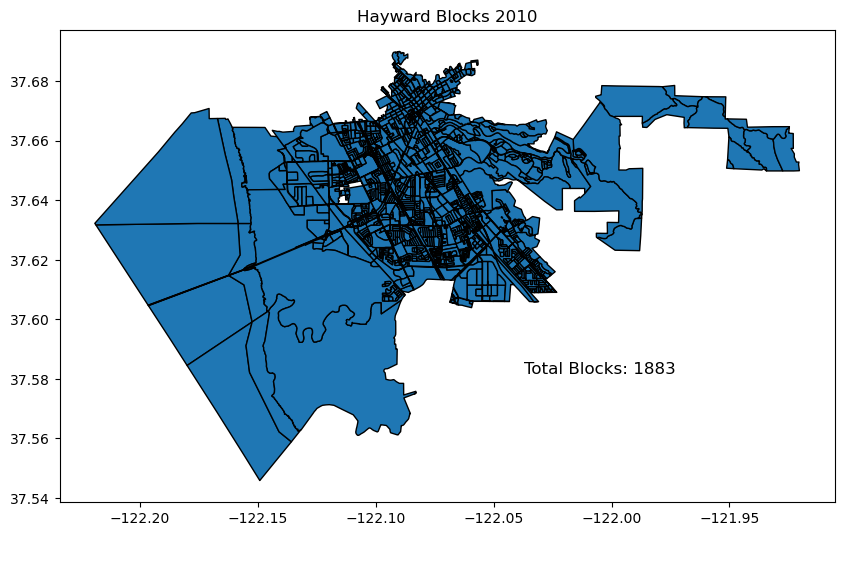

In [8]:
# map Hayward blocks
city_blocks_gdf = tabblock_dict_gdf['2010'][tabblock_dict_gdf['2010']['placeNAME10'] == 'Hayward']
# plot city blocks
city_blocks_gdf.plot(figsize=(10,10), edgecolor='black')
plt.title('Hayward Blocks 2010')
# add note on the count of blocks
num_blocks = city_blocks_gdf.shape[0]
plt.annotate(f'Total Blocks: {num_blocks}', xy=(0.6, 0.2), xycoords='figure fraction', ha='center', fontsize=12)

In [9]:
tabblock_df = pd.read_csv("OutputData\\tl_2020_Hayward_CA_NSI_tabblockplacepuma20EPSG4269.csv")
tabblock_dict_gdf['2020'] = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)


Converting geometry to Geodataframe


In [10]:
# create a blockid based on BLOCKID20_str minus B
tabblock_dict_gdf['2020']['blockid'] = tabblock_dict_gdf['2020']['BLOCKID20_str'].str.replace('B', '')
# move blockid to the front of the dataframe
cols = tabblock_dict_gdf['2020'].columns.tolist()
cols.insert(0, cols.pop(cols.index('blockid')))
tabblock_dict_gdf['2020'] = tabblock_dict_gdf['2020'][cols]
tabblock_dict_gdf['2020'].head(1)

,blockid,BLOCKID20,BLOCKID20_str,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,NAME20,MTFCC20,...,INTPTLAT20,INTPTLON20,geometry,rppnt204269,blk204269,placeGEOID20,placeNAME20,placeNAMELSAD20,pumaGEOID20,pumaNAMELSAD20
0,060014324003003,60014324003003,B060014324003003,6,1,432400,3003,60014324003003,Block 3003,G5040,...,37.72317,-122.195658,"POLYGON ((-122.2 37.724, -122.2 37.724, -122.2...",POINT (-122.1956479613675 37.723157),POLYGON ((-122.1967109040613 37.72410619135865...,668084.0,San Leandro,San Leandro city,600114,"Alameda County (West)--San Leandro, Alameda, E..."


Text(0.6, 0.2, 'Total Blocks: 1488')

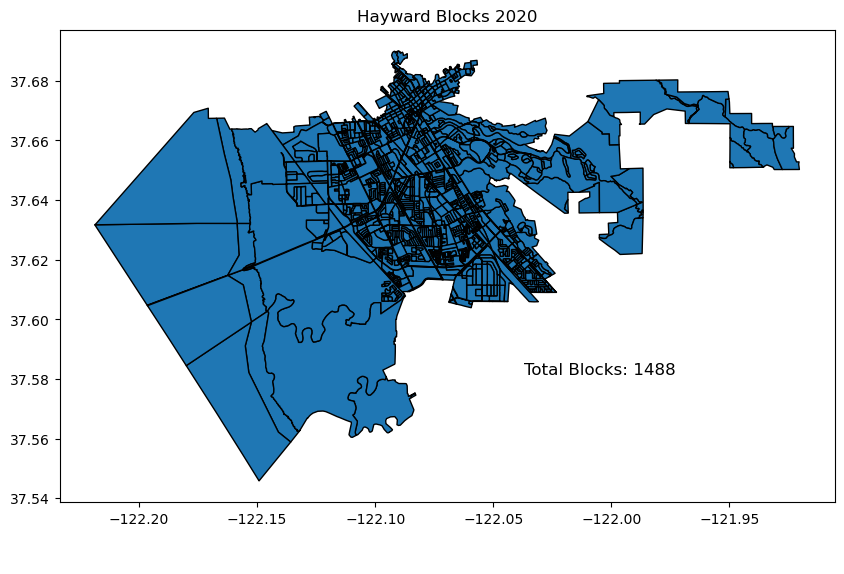

In [11]:
# map Hayward blocks
city_blocks_gdf = tabblock_dict_gdf['2020'][tabblock_dict_gdf['2020']['placeNAME20'] == 'Hayward']
# plot city blocks
city_blocks_gdf.plot(figsize=(10,10), edgecolor='black')
plt.title('Hayward Blocks 2020')
# add note on the count of blocks
num_blocks = city_blocks_gdf.shape[0]
plt.annotate(f'Total Blocks: {num_blocks}', xy=(0.6, 0.2), xycoords='figure fraction', ha='center', fontsize=12)

In [12]:
huest_df_dict = {}

In [13]:
huest_path_2010 = r"OutputData\huest_v2-2-0_Hayward_CA_NSI_2010_NSI.csv"
huest_path_2020 = r"OutputData\huest_v2-2-0_Hayward_CA_NSI_2020_NSI.csv"

huest_df_dict['2010'] = pd.read_csv(huest_path_2010)
huest_df_dict['2020'] = pd.read_csv(huest_path_2020)

In [14]:
huest_df_dict['2010'].head()

,blockBLOCKID10_str,fd_id_bid,blockplaceNAME10,occtype,sqft,huestimate,residential,apcount,bldgcount,residentialAP1,...,residentialAP2v2,residentialAP2v2_sum,bldgcountv2_sum,DiffCount2,ErrorCheck2_int,residentialAP2v3_sum,bldgcountv3_sum,DiffCount3,ErrorCheck3_int,d_sf
0,B060014001001000,nsi-474712228-849VVQJ4+7Q7-3-4-2-4,Oakland,GOV1,2494.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN
1,B060014001001000,nsi-474712229-849VVQJ5+72F-2-2-2-2,Oakland,GOV1,19000.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN
2,B060014001001000,nsi-474712230-849VVQJ4+7XV-2-2-2-2,Oakland,GOV1,19000.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN
3,B060014001001000,nsi-474712231-849VVQJ5+C39-7-6-7-5,Oakland,GOV1,7470.5,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN
4,B060014001001000,nsi-474712232-849VVQJ5+G57-2-2-1-3,Oakland,GOV1,19000.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN


In [15]:
# Mean absolute error by block: mean(|assigned - expected|) across buildings in each block
for yr in ['2010', '2020']:
    block_col = f"blockBLOCKID{yr[2:4]}_str"
    df = huest_df_dict[yr].copy(deep=True)

    # Building-level absolute error between assigned and expected units
    df['abs_error_assigned_expected'] = (df['huestimate'] - df['residentialAP1']).abs()

    huest_df_dict[yr] = df

# Quick check
huest_df_dict['2010'][[
    'blockBLOCKID10_str','fd_id_bid','huestimate', 'residentialAP1',
    'abs_error_assigned_expected'
]].head()

,blockBLOCKID10_str,fd_id_bid,huestimate,residentialAP1,abs_error_assigned_expected
0,B060014001001000,nsi-474712228-849VVQJ4+7Q7-3-4-2-4,0.0,0.0,0.0
1,B060014001001000,nsi-474712229-849VVQJ5+72F-2-2-2-2,0.0,0.0,0.0
2,B060014001001000,nsi-474712230-849VVQJ4+7XV-2-2-2-2,0.0,0.0,0.0
3,B060014001001000,nsi-474712231-849VVQJ5+C39-7-6-7-5,0.0,0.0,0.0
4,B060014001001000,nsi-474712232-849VVQJ5+G57-2-2-1-3,0.0,0.0,0.0


In [40]:
# Block-level summary table for each year
huest_block_summary_dict = {}

for yr in ['2010', '2020']:
    block_col = f"blockBLOCKID{yr[2:4]}_str"
    df = huest_df_dict[yr].copy(deep=True)

    huest_block_summary_dict[yr] = (
        df.groupby(block_col, as_index=False)
          .agg(
              huestimate=('huestimate', 'sum'),
              building_count=('fd_id_bid', 'count'),
              huexpected=('residentialAP1', 'sum'),
              total_sqfootage=('sqft', 'sum'),
              mean_abs_error_block=('abs_error_assigned_expected', 'mean')
          )
          .sort_values(block_col)
          .reset_index(drop=True)
    )

    # rename blockBLOCKID10_str = BLOCKID10_str
    huest_block_summary_dict[yr] = huest_block_summary_dict[yr].rename(columns={block_col: f'BLOCKID{yr[2:4]}_str'})
    print(f"Year {yr}: {huest_block_summary_dict[yr].shape[0]} blocks summarized")

    # add percent change between huestimate and huexpected
    huest_block_summary_dict[yr]['percent_change'] = (
        (huest_block_summary_dict[yr]['huestimate'] - huest_block_summary_dict[yr]['huexpected']) /
        huest_block_summary_dict[yr]['huexpected'].replace(0, np.nan)
    ) * 100

    # add square footage per unit
    huest_block_summary_dict[yr]['sqft_per_unit'] = (
        huest_block_summary_dict[yr]['total_sqfootage'] /
        huest_block_summary_dict[yr]['huestimate'].replace(0, np.nan)
    )

# Quick check
huest_block_summary_dict['2010'].head()

Year 2010: 16341 blocks summarized
Year 2020: 14869 blocks summarized


,BLOCKID10_str,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
0,B060014001001000,0.0,8,0.0,74740.740,0.0,NaN,NaN
1,B060014001001007,94.0,84,52.0,359893.735,0.5,80.769231,3828.656755
2,B060014001001008,10.0,10,10.0,27319.000,0.0,0.000000,2731.900000
3,B060014001001009,0.0,4,0.0,28491.000,0.0,NaN,NaN
4,B060014001001010,0.0,8,0.0,98513.560,0.0,NaN,NaN


In [41]:
huest_block_summary_dict['2020'].head()

,BLOCKID20_str,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
0,B060014001001001,0.0,9,0.0,76374.74,0.0,NaN,NaN
1,B060014001001003,0.0,23,0.0,217980.49,0.0,NaN,NaN
2,B060014001001005,0.0,18,0.0,245352.93,0.0,NaN,NaN
3,B060014001001007,0.0,2,0.0,17890.00,0.0,NaN,NaN
4,B060014001001009,5.0,5,5.0,11402.00,0.0,0.0,2280.4


In [63]:
tabblock_huest_dict_gdf = {}

# Add block-level HUEST summary columns directly to tabblock_dict_gdf for mapping
for yr in ['2010', '2020']:
    block_col = f"BLOCKID{yr[2:4]}_str"

    # Keep geometry from tabblock_dict_gdf; add summarized HUEST-by-block attributes
    tabblock_huest_dict_gdf[yr] = pd.merge(
        tabblock_dict_gdf[yr],
        huest_block_summary_dict[yr],
        on=block_col,
        how='left'
    )

    print(
        f"Year {yr}: tabblock_huest_dict_gdf updated with HUEST block summary "
        f"({tabblock_huest_dict_gdf[yr].shape[0]} records)"
    )

# Quick check
tabblock_huest_dict_gdf['2010'].head()

Year 2010: tabblock_huest_dict_gdf updated with HUEST block summary (23956 records)
Year 2020: tabblock_huest_dict_gdf updated with HUEST block summary (18475 records)


,BLOCKID10,BLOCKID10_str,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,UR10,...,placeNAMELSAD10,pumaGEOID10,pumaNAMELSAD10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
0,60014507013017,B060014507013017,6,1,450701,3017,60014507013017,Block 3017,G5040,R,...,Sunol CDP,600110,"Alameda County (East)--Livermore, Pleasanton &...",43.0,82.0,43.0,708754.714640,0.0,0.0,16482.667782
1,60019900000022,B060019900000022,6,1,990000,22,60019900000022,Block 0022,G5040,R,...,Hayward city,600105,"Alameda County (West)--San Leandro, Alameda & ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60014359003019,B060014359003019,6,1,435900,3019,60014359003019,Block 3019,G5040,R,...,San Lorenzo CDP,600106,"Alameda County (North Central)--Castro Valley,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60014282002011,B060014282002011,6,1,428200,2011,60014282002011,Block 2011,G5040,U,...,Alameda city,600105,"Alameda County (West)--San Leandro, Alameda & ...",211.0,88.0,211.0,264030.739954,0.0,0.0,1251.330521
4,60014415031031,B060014415031031,6,1,441503,1031,60014415031031,Block 1031,G5040,R,...,Fremont city,600108,"Alameda County (Southwest)--Union City, Newark...",0.0,1.0,0.0,19000.000000,0.0,NaN,NaN


In [64]:
# Describe block-level mean absolute error for 2010 and 2020
for yr in ['2010', '2020']:
    print(f"Year {yr} - Mean Absolute Error by Block:")
    print(tabblock_huest_dict_gdf[yr]['mean_abs_error_block'].describe())

Year 2010 - Mean Absolute Error by Block:
count    16120.000000
mean         0.459969
std          3.519075
min          0.000000
25%          0.000000
50%          0.000000
75%          0.333333
max        263.000000
Name: mean_abs_error_block, dtype: float64
Year 2020 - Mean Absolute Error by Block:
count    14668.000000
mean         0.684439
std          5.191147
min          0.000000
25%          0.000000
50%          0.000000
75%          0.804348
max        265.000000
Name: mean_abs_error_block, dtype: float64


In [65]:
# Describe mean absolute error by place for 2010 and 2020
for yr in ['2010', '2020']:
    place_col = f"placeNAME{yr[2:4]}"
    print(f"Year {yr} - Mean Absolute Error by Place:")

    place_summary = (
        tabblock_huest_dict_gdf[yr]
        .groupby(place_col, dropna=False)['mean_abs_error_block']
        .describe()
        .sort_index()
    )

    print(place_summary)

Year 2010 - Mean Absolute Error by Place:
                count      mean       std  min  25%    50%       75%  \
placeNAME10                                                            
Alameda         908.0  0.431935  2.022314  0.0  0.0  0.000  0.666667   
Albany          175.0  0.907943  3.093624  0.0  0.0  0.000  0.945788   
Ashland         144.0  0.466042  0.780635  0.0  0.0  0.000  0.882919   
Berkeley       1375.0  0.531914  1.806524  0.0  0.0  0.000  0.909091   
Castro Valley   506.0  0.255865  0.550249  0.0  0.0  0.000  0.000000   
Cherryland      109.0  0.283056  0.646171  0.0  0.0  0.000  0.505747   
Dublin          499.0  0.709690  6.012006  0.0  0.0  0.000  0.000000   
Emeryville      137.0  1.541166  5.490419  0.0  0.0  0.000  0.500000   
Fairview         81.0  0.205612  0.399582  0.0  0.0  0.000  0.000000   
Fremont        1811.0  0.453610  4.792561  0.0  0.0  0.000  0.000000   
Hayward        1279.0  0.397990  3.249649  0.0  0.0  0.000  0.000000   
Livermore      1118.0 

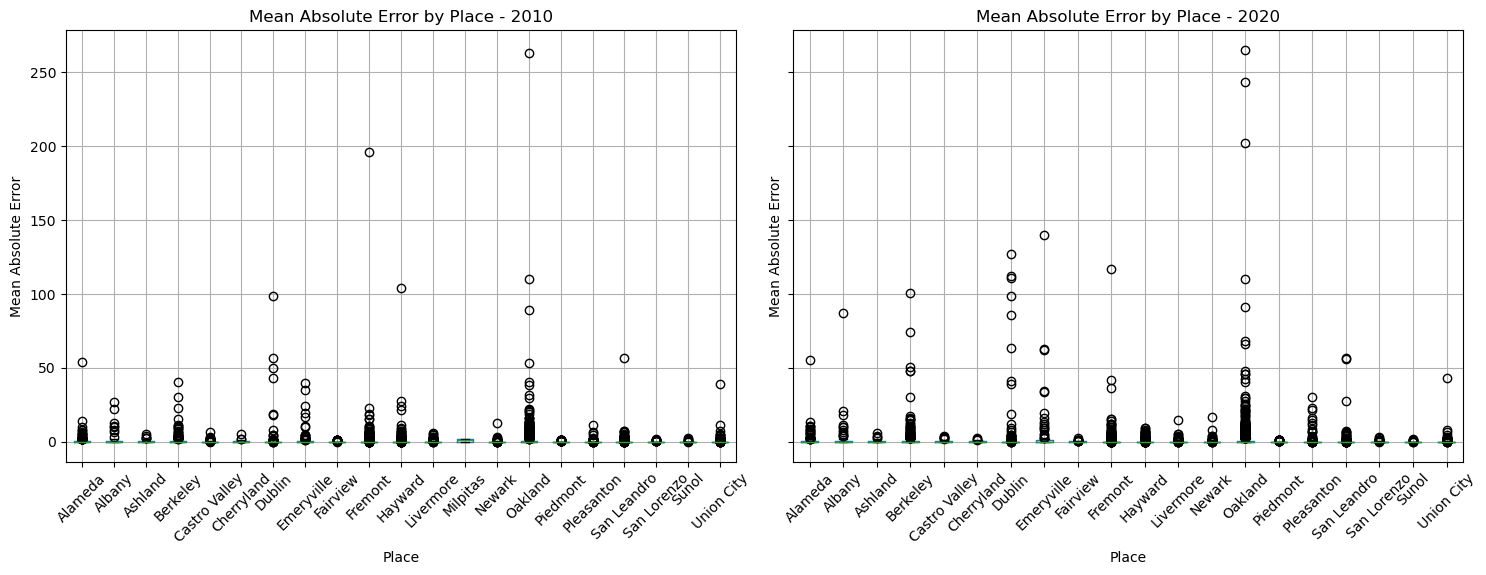

In [66]:
# do side by side boxplot of mean_abs_error_block by place for 2010 and 2020
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for i, yr in enumerate(['2010', '2020']):
    place_col = f"placeNAME{yr[2:4]}"
    tabblock_huest_dict_gdf[yr].boxplot(column='mean_abs_error_block', by=place_col, ax=axes[i])
    axes[i].set_title(f'Mean Absolute Error by Place - {yr}')
    axes[i].set_xlabel('Place')
    axes[i].set_ylabel('Mean Absolute Error')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('')  # Suppress the default title to avoid redundancy
plt.tight_layout()
plt.show()

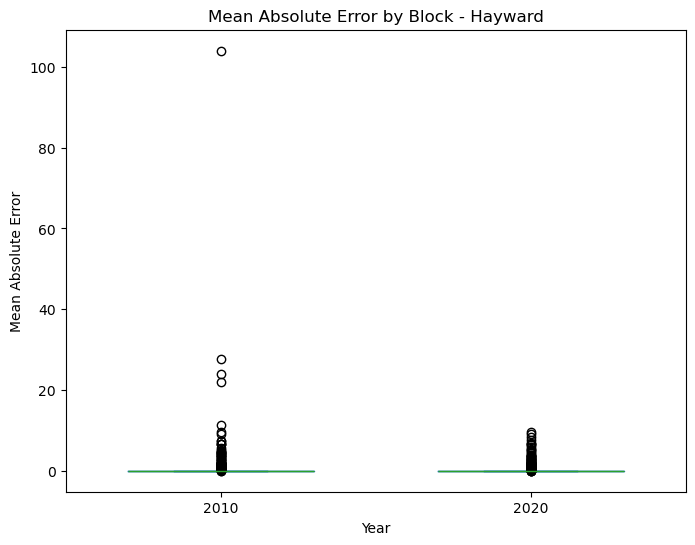

In [67]:
# make the box plot just for Hayward for 2010 and 2020
fig, ax = plt.subplots(figsize=(8, 6))
for yr in ['2010', '2020']:
    place_col = f"placeNAME{yr[2:4]}"
    hayward_data = tabblock_huest_dict_gdf[yr][tabblock_huest_dict_gdf[yr][place_col] == 'Hayward']['mean_abs_error_block']
    hayward_data.plot(kind='box', ax=ax, positions=[0 if yr == '2010' else 1], widths=0.6)
ax.set_title('Mean Absolute Error by Block - Hayward')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Absolute Error')
ax.set_xticks([0, 1])
ax.set_xticklabels(['2010', '2020'])
plt.show()


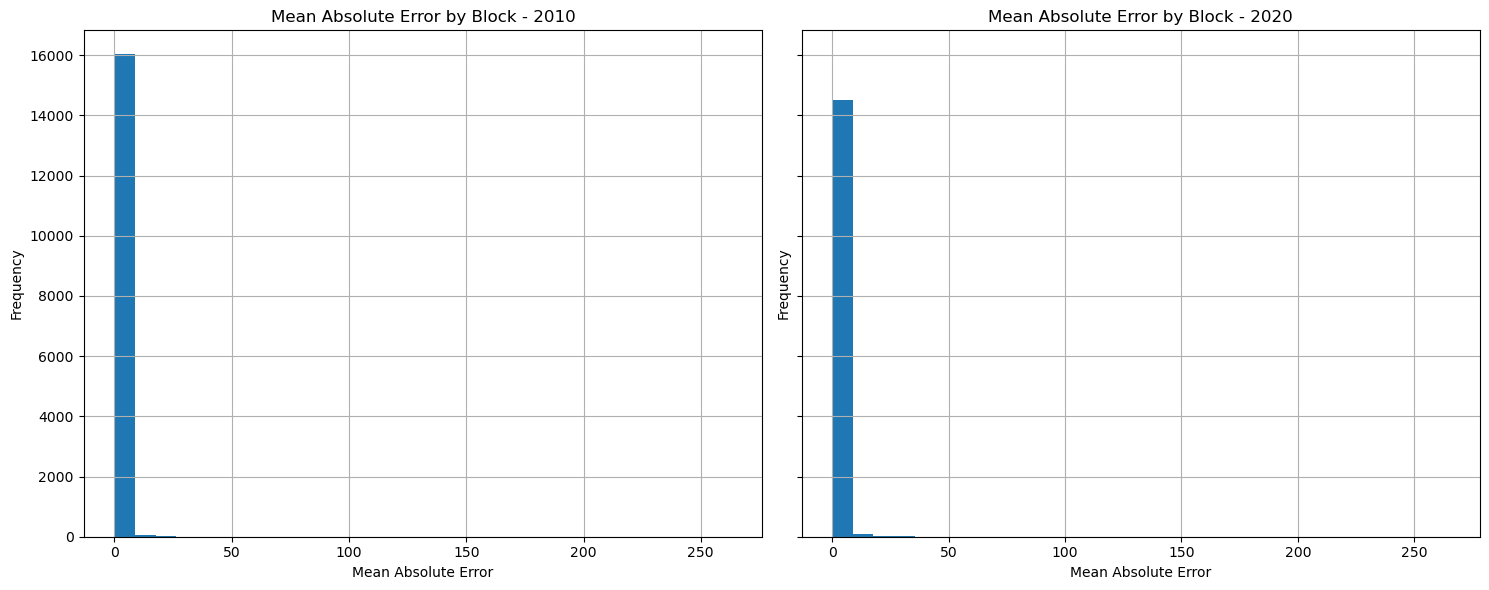

In [68]:
# make a histogram of mean_abs_error_block for all blocks in county overlap 2010 and 2020
# put plots on the same scale for comparison, use kernel density and drop zero values

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for i, yr in enumerate(['2010', '2020']):
    tabblock_huest_dict_gdf[yr]['mean_abs_error_block'].hist(ax=axes[i], bins=30)
    axes[i].set_title(f'Mean Absolute Error by Block - {yr}')
    axes[i].set_xlabel('Mean Absolute Error')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


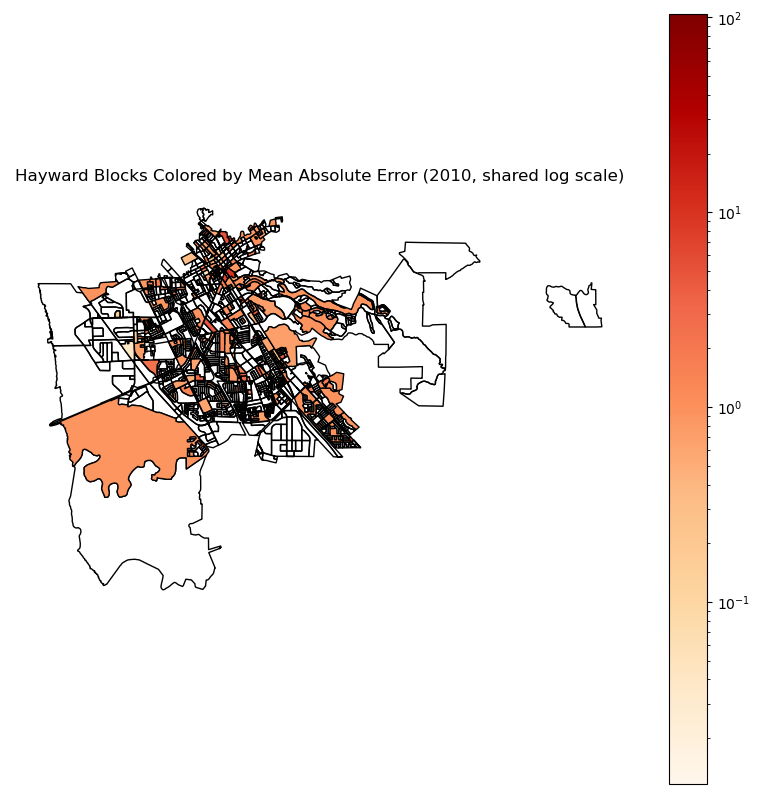

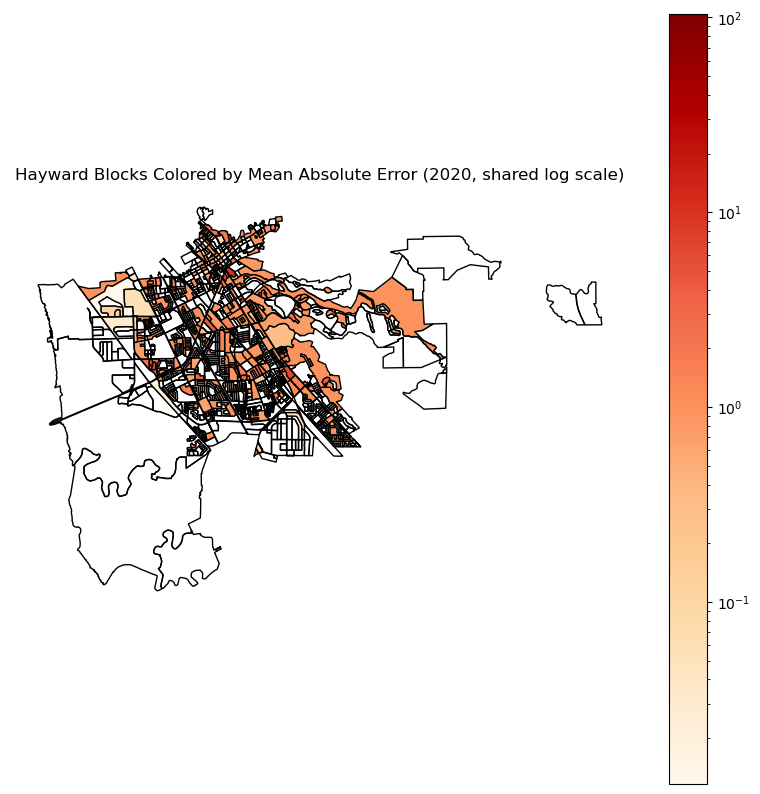

In [69]:
# Map Hayward blocks colored by mean absolute error (shared log color scale)
from matplotlib.colors import LogNorm

focalplace = 'Hayward'
years = ['2010', '2020']

# Build one shared positive range across all years for consistent color scaling
all_positive_vals = []
for yr in years:
    place_col = f"placeNAME{yr[2:4]}"
    vals = tabblock_huest_dict_gdf[yr].loc[
        tabblock_huest_dict_gdf[yr][place_col] == focalplace,
        'mean_abs_error_block'
    ].replace([np.inf, -np.inf], np.nan)
    all_positive_vals.append(vals[vals > 0])

all_positive_vals = pd.concat(all_positive_vals, ignore_index=True)

if all_positive_vals.empty:
    print("No positive mean_abs_error_block values found across years for log-scale plotting.")
else:
    shared_vmin = all_positive_vals.min()
    shared_vmax = all_positive_vals.max()
    shared_norm = LogNorm(vmin=shared_vmin, vmax=shared_vmax)

    for yr in years:
        place_col = f"placeNAME{yr[2:4]}"
        block_gdf = tabblock_huest_dict_gdf[yr][
            tabblock_huest_dict_gdf[yr][place_col] == focalplace
        ].copy(deep=True)

        positive_vals = block_gdf['mean_abs_error_block'].replace([np.inf, -np.inf], np.nan)
        positive_vals = positive_vals[positive_vals > 0]

        if positive_vals.empty:
            print(f"Year {yr}: no positive mean_abs_error_block values to plot on shared log scale.")
            continue

        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
        block_gdf.plot(
            column='mean_abs_error_block',
            ax=ax,
            legend=True,
            cmap='OrRd',
            edgecolor='black',
            norm=shared_norm
        )
        ax.set_title(f"{focalplace} Blocks Colored by Mean Absolute Error ({yr}, shared log scale)")
        ax.axis('off')
        plt.show()

### Look at Error By Housing Unit Inventory Variables


In [70]:
hua_df_dict = {}

In [71]:
hua_path_2010 = r"OutputData\hua_v2-2-0_Hayward_CA_NSI_2010_rs9876_NSI.csv"
hua_path_2020 = r"OutputData\hua_v2-2-0_Hayward_CA_NSI_2020_rs9876_NSI.csv"

hua_df_dict['2010'] = pd.read_csv(hua_path_2010)
hua_df_dict['2020'] = pd.read_csv(hua_path_2020)

In [72]:
hua_df_dict['2010'].head()

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,incomegroup,hhinc,randincome,poverty,BLOCKID10_str,fd_id_bid,placeNAME10,huestimate,x,y
0,B060014001001007H0001,60014001001007,60014001001,6001400100,6001,1,1.0,1.0,0.0,0.0,...,13.0,5.0,122331.0,0.0,B060014001001007,nsi-474648750-849VVQ65+J2C-2-2-3-3,Oakland,2.0,-122.242497,37.861551
1,B060014001001007H0002,60014001001007,60014001001,6001400100,6001,1,1.0,1.0,0.0,0.0,...,16.0,5.0,249702.0,0.0,B060014001001007,nsi-474648764-849VVQ65+PW4-1-3-2-2,Oakland,2.0,-122.240157,37.861752
2,B060014001001007H0003,60014001001007,60014001001,6001400100,6001,1,1.0,1.0,0.0,0.0,...,12.0,4.0,81115.0,0.0,B060014001001007,nsi-474648761-849VVQ64+JV4-5-4-3-3,Oakland,2.0,-122.242793,37.861523
3,B060014001001007H0004,60014001001007,60014001001,6001400100,6001,1,1.0,1.0,0.0,0.0,...,15.0,5.0,185826.0,0.0,B060014001001007,nsi-474648762-849VVQ65+MC5-2-3-2-3,Oakland,2.0,-122.241380,37.861648
4,B060014001001007H0005,60014001001007,60014001001,6001400100,6001,1,1.0,1.0,0.0,0.0,...,15.0,5.0,173579.0,0.0,B060014001001007,nsi-474648765-849VVQ64+PQ7-2-2-2-3,Oakland,2.0,-122.243089,37.861795


In [73]:
huest_df_dict['2010'].head()

,blockBLOCKID10_str,fd_id_bid,blockplaceNAME10,occtype,sqft,huestimate,residential,apcount,bldgcount,residentialAP1,...,residentialAP2v2_sum,bldgcountv2_sum,DiffCount2,ErrorCheck2_int,residentialAP2v3_sum,bldgcountv3_sum,DiffCount3,ErrorCheck3_int,d_sf,abs_error_assigned_expected
0,B060014001001000,nsi-474712228-849VVQJ4+7Q7-3-4-2-4,Oakland,GOV1,2494.0,0.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN,0.0
1,B060014001001000,nsi-474712229-849VVQJ5+72F-2-2-2-2,Oakland,GOV1,19000.0,0.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN,0.0
2,B060014001001000,nsi-474712230-849VVQJ4+7XV-2-2-2-2,Oakland,GOV1,19000.0,0.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN,0.0
3,B060014001001000,nsi-474712231-849VVQJ5+C39-7-6-7-5,Oakland,GOV1,7470.5,0.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN,0.0
4,B060014001001000,nsi-474712232-849VVQJ5+G57-2-2-1-3,Oakland,GOV1,19000.0,0.0,0.0,0.0,1.0,0.0,...,0.0,8.0,0.0,1,0.0,8.0,0.0,1,NaN,0.0


In [74]:
# merge huest_df_dict['2010'] with hua_df_dict['2010'] on fd_id_bid to compare huestimate and hua
huest_hua_2010_df = pd.merge(
    huest_df_dict['2010'],
    hua_df_dict['2010'],
    on='fd_id_bid',
    how='right'
)

In [75]:
huest_hua_2010_df.head()

,blockBLOCKID10_str,fd_id_bid,blockplaceNAME10,occtype,sqft,huestimate_x,residential,apcount,bldgcount,residentialAP1,...,gqtype,incomegroup,hhinc,randincome,poverty,BLOCKID10_str,placeNAME10,huestimate_y,x,y
0,B060014001001007,nsi-474648750-849VVQ65+J2C-2-2-3-3,Oakland,RES1-3SNB,4097.0,2.0,1.0,57.0,1.0,1.0,...,0.0,13.0,5.0,122331.0,0.0,B060014001001007,Oakland,2.0,-122.242497,37.861551
1,B060014001001007,nsi-474648764-849VVQ65+PW4-1-3-2-2,Oakland,RES1-3SNB,2646.0,2.0,1.0,57.0,1.0,1.0,...,0.0,16.0,5.0,249702.0,0.0,B060014001001007,Oakland,2.0,-122.240157,37.861752
2,B060014001001007,nsi-474648761-849VVQ64+JV4-5-4-3-3,Oakland,RES1-2SNB,3340.0,2.0,1.0,57.0,1.0,1.0,...,0.0,12.0,4.0,81115.0,0.0,B060014001001007,Oakland,2.0,-122.242793,37.861523
3,B060014001001007,nsi-474648762-849VVQ65+MC5-2-3-2-3,Oakland,RES1-3SWB,2238.0,2.0,1.0,57.0,1.0,1.0,...,0.0,15.0,5.0,185826.0,0.0,B060014001001007,Oakland,2.0,-122.241380,37.861648
4,B060014001001007,nsi-474648765-849VVQ64+PQ7-2-2-2-3,Oakland,RES1-2SNB,1291.0,2.0,1.0,57.0,1.0,1.0,...,0.0,15.0,5.0,173579.0,0.0,B060014001001007,Oakland,2.0,-122.243089,37.861795


In [76]:
# describe abs_error_assigned_expected for huest_hua_2010_df by tenure
huest_hua_2010_df.groupby('ownershp')['abs_error_assigned_expected'].describe()

,count,mean,std,min,25%,50%,75%,max
ownershp,,,,,,,,
1.0,291137.0,1.328509,18.854721,0.0,0.0,0.0,1.0,672.0
2.0,253685.0,9.943339,42.993607,0.0,0.0,1.0,2.0,672.0


In [77]:
huest_hua_2010_df.groupby('poverty')['abs_error_assigned_expected'].describe()

,count,mean,std,min,25%,50%,75%,max
poverty,,,,,,,,
0.0,483579.0,5.229019,33.198375,0.0,0.0,0.0,1.0,672.0
1.0,61243.0,6.214751,28.419257,0.0,0.0,0.0,1.0,672.0


In [78]:
huest_hua_2010_df.groupby('race')['abs_error_assigned_expected'].describe()

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
1.0,271672.0,4.780717,33.102354,0.0,0.0,0.0,1.0,672.0
2.0,78003.0,6.396946,29.263172,0.0,0.0,1.0,1.0,672.0
3.0,3146.0,3.504768,17.578825,0.0,0.0,0.0,1.0,339.0
4.0,125708.0,6.816344,38.113225,0.0,0.0,0.0,1.0,672.0
5.0,3290.0,3.210638,20.837242,0.0,0.0,0.0,1.0,672.0
6.0,40322.0,2.663087,16.040518,0.0,0.0,0.0,1.0,672.0
7.0,22681.0,5.539747,31.044690,0.0,0.0,0.0,1.0,672.0


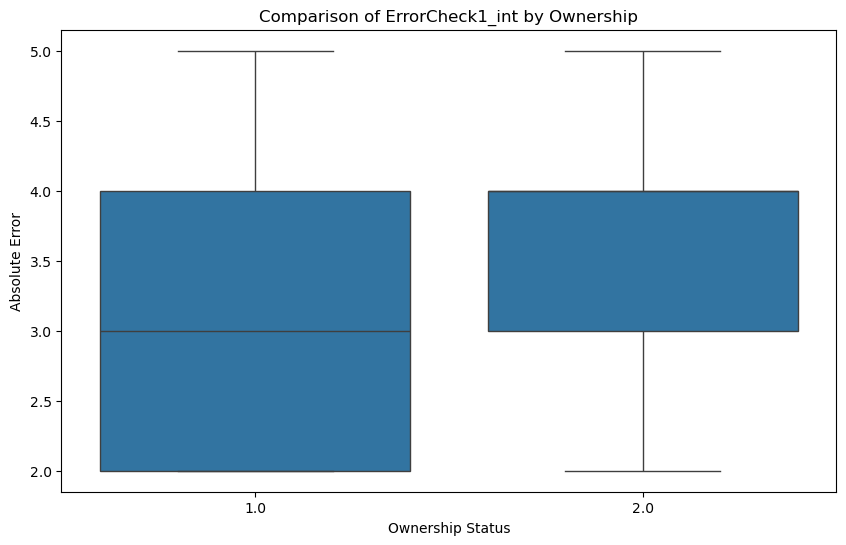

In [79]:
# generate whisker plot comparing abs_error_assigned_expected by tenure

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=huest_hua_2010_df, x='ownershp', y='ErrorCheck1_int')
plt.title('Comparison of ErrorCheck1_int by Ownership')
plt.xlabel('Ownership Status')
plt.ylabel('Absolute Error')
plt.show()

## Explore one block

060014373002012

In [80]:
block = 'B060014373002012'

In [81]:
tabblock_huest_dict_gdf['2010'].head()

,BLOCKID10,BLOCKID10_str,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,UR10,...,placeNAMELSAD10,pumaGEOID10,pumaNAMELSAD10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
0,60014507013017,B060014507013017,6,1,450701,3017,60014507013017,Block 3017,G5040,R,...,Sunol CDP,600110,"Alameda County (East)--Livermore, Pleasanton &...",43.0,82.0,43.0,708754.714640,0.0,0.0,16482.667782
1,60019900000022,B060019900000022,6,1,990000,22,60019900000022,Block 0022,G5040,R,...,Hayward city,600105,"Alameda County (West)--San Leandro, Alameda & ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60014359003019,B060014359003019,6,1,435900,3019,60014359003019,Block 3019,G5040,R,...,San Lorenzo CDP,600106,"Alameda County (North Central)--Castro Valley,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60014282002011,B060014282002011,6,1,428200,2011,60014282002011,Block 2011,G5040,U,...,Alameda city,600105,"Alameda County (West)--San Leandro, Alameda & ...",211.0,88.0,211.0,264030.739954,0.0,0.0,1251.330521
4,60014415031031,B060014415031031,6,1,441503,1031,60014415031031,Block 1031,G5040,R,...,Fremont city,600108,"Alameda County (Southwest)--Union City, Newark...",0.0,1.0,0.0,19000.000000,0.0,NaN,NaN


In [85]:
# sort based on percent change and then filter for Hayward
placename = 'Hayward'
condition = tabblock_huest_dict_gdf['2010']['placeNAME10'] == placename
sorted_hayward_2010 = tabblock_huest_dict_gdf['2010'][condition].sort_values('percent_change', ascending=False)
sorted_hayward_2010[['BLOCKID10_str','placeNAME10',
                     'huestimate', 'building_count', 'huexpected', 
                     'total_sqfootage', 'mean_abs_error_block', 'percent_change', 
                     'sqft_per_unit']].head(10)

,BLOCKID10_str,placeNAME10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
923,B060014366021003,Hayward,210.0,2.0,2.0,11200.00000,104.000000,10400.000000,53.333333
6776,B060014372001013,Hayward,25.0,1.0,1.0,7884.00000,24.000000,2400.000000,315.360000
18544,B060014351042008,Hayward,160.0,7.0,7.0,7646.48500,21.857143,2185.714286,47.790531
19241,B060014377013001,Hayward,90.0,30.0,6.0,62971.70000,2.800000,1400.000000,699.685556
3387,B060014365002019,Hayward,560.0,18.0,61.0,64726.37000,27.722222,818.032787,115.582804
12779,B060014354003015,Hayward,25.0,3.0,3.0,3570.00000,7.333333,733.333333,142.800000
9691,B060014354002045,Hayward,23.0,3.0,3.0,17146.87000,6.666667,666.666667,745.516087
13615,B060014372001043,Hayward,6.0,6.0,1.0,35034.99990,0.833333,500.000000,5839.166650
7688,B060014381005004,Hayward,70.0,12.0,12.0,47236.35500,4.833333,483.333333,674.805071
15389,B060014365002025,Hayward,117.0,22.0,21.0,83156.09999,4.363636,457.142857,710.735897


In [ ]:
from pyncoda.ncoda_08a_check_block import BlockValidationChecker


In [ ]:
from pyncoda.ncoda_00e_geoutilities import df2gdf_WKTgeometry

tabblock_df = pd.read_csv("OutputData\\tl_2010_Hayward_CA_NSI_tabblockplacepuma10EPSG4269.csv")
tabblock_gdf = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)

In [ ]:

nsi_path = r"OutputData\00_SourceData\nsi_sec_usace_army_mil\nsi_01av1_hua_06001.shp"
addpt_path = r"OutputData\addpt_v2-2-0_Hayward_CA_NSI_2010_NSI.csv"

nsi_gdf = gpd.read_file(nsi_path)
addpt_df = pd.read_csv(addpt_path)

checker = BlockValidationChecker(
    hua_gdf=focalplace_hua_gdf,
    tabblock_gdf=tabblock_huest_dict_gdf[yr],
    nsi_gdf=nsi_gdf,
    addpt_df=addpt_df,
    block_col="blockid",
    block_col_tab="blockid",
    bldg_uniqueid="fd_id_bid",
    addpt_structure_id="strctid",
    addpt_occtype_col="occtype",
    bldg_archetype_col="occtype",
    hua_unit_col="huid",
)

In [83]:
condition = tabblock_huest_dict_gdf['2010']['BLOCKID10_str'] == block
tabblock_huest_dict_gdf['2010'][condition].head()

,BLOCKID10,BLOCKID10_str,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,UR10,...,placeNAMELSAD10,pumaGEOID10,pumaNAMELSAD10,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block,percent_change,sqft_per_unit
9631,60014373002012,B060014373002012,6,1,437300,2012,60014373002012,Block 2012,G5040,U,...,Hayward city,600107,Alameda County (Central)--Hayward City PUMA,255.0,49.0,117.0,176212.71,2.816327,117.948718,691.030235


In [ ]:
huest_block_summary_dict['2010'][huest_block_summary_dict['2010']['BLOCKID10_str'] == block][[
    'BLOCKID10_str', 'huestimate', 'building_count', 'huexpected', 'total_sqfootage', 'mean_abs_error_block'
]].head()

,BLOCKID10_str,huestimate,building_count,huexpected,total_sqfootage,mean_abs_error_block
10145,B060014373002012,255.0,49,117.0,176212.71,2.816327


In [ ]:

# filter huest_hua_2010_df for block
condition = huest_hua_2010_df['blockBLOCKID10_str'] == block
huest_hua_2010_df_block = huest_hua_2010_df[condition]
huest_hua_2010_df_block.head()

,blockBLOCKID10_str,fd_id_bid,blockplaceNAME10,occtype,sqft,huestimate_x,residential,apcount,bldgcount,residentialAP1,...,gqtype,incomegroup,hhinc,randincome,poverty,BLOCKID10_str,placeNAME10,huestimate_y,x,y
53886,B060014373002012,nsi-475044758-849VJWM4+FQ2-4-1-3-1,Hayward,RES3A,1027.75,3.0,1.0,252.0,1.0,2.0,...,0.0,5.0,3.0,26458.0,0.0,B060014373002012,Hayward,3.0,-122.093096,37.633646
53887,B060014373002012,nsi-475044751-849VJWM4+8G9-9-3-8-3,Hayward,RES3B,6874.00,9.0,1.0,252.0,1.0,3.0,...,0.0,5.0,3.0,28988.0,0.0,B060014373002012,Hayward,9.0,-122.093638,37.633289
53888,B060014373002012,nsi-475044389-849VJWJ5+Q2G-2-8-2-8,Hayward,RES3B,4342.25,7.0,1.0,252.0,1.0,3.0,...,0.0,2.0,1.0,12672.0,0.0,B060014373002012,Hayward,7.0,-122.092429,37.631942
79055,B060014373002012,nsi-475044400-849VJWJ5+W24-4-4-4-3,Hayward,RES3B,4509.75,7.0,1.0,252.0,1.0,3.0,...,0.0,1.0,1.0,5192.0,1.0,B060014373002012,Hayward,7.0,-122.092405,37.632261
110116,B060014373002012,nsi-475044399-849VJWJ4+VV2-9-3-8-4,Hayward,RES3B,6876.00,9.0,1.0,252.0,1.0,3.0,...,0.0,0.0,0.0,NaN,NaN,B060014373002012,Hayward,9.0,-122.092871,37.632140
